Loan Approval Prediction
🎯 Real-world problem

A bank wants to predict:

Should this customer's loan be approved or rejected?

The model will use multiple factors:

Feature	Meaning
Age	Customer age
Income	Annual income
Credit Score	Creditworthiness
Loan Amount	Amount requested
Employment Years	Years employed
Existing Loans	Number of current loans
Dependents	Number of dependents
Loan Term	Requested loan duration
Approval	Target

Target:

0 → Rejected
1 → Approved

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    "age": [
        22, 25, 28, 31, 35, 38, 42, 45,
        24, 27, 30, 33, 36, 40, 44, 48,
        26, 29, 32, 37, 41, 43, 47, 50,
        34, 39, 46, 52, 55, 58, 23, 49
    ],

    "income": [
        25000, 30000, 35000, 42000, 50000, 55000, 65000, 70000,
        28000, 33000, 38000, 45000, 52000, 60000, 68000, 75000,
        32000, 40000, 48000, 58000, 63000, 72000, 80000, 90000,
        47000, 62000, 85000, 95000, 105000, 120000, 27000, 78000
    ],

    "credit_score": [
        580, 600, 620, 640, 680, 700, 720, 750,
        590, 610, 630, 650, 690, 710, 730, 760,
        605, 625, 645, 670, 705, 725, 745, 780,
        660, 715, 735, 755, 790, 810, 570, 770
    ],

    "loan_amount": [
        150000, 180000, 200000, 250000, 300000, 350000, 400000, 450000,
        160000, 190000, 220000, 270000, 310000, 360000, 420000, 480000,
        170000, 210000, 240000, 290000, 340000, 390000, 460000, 500000,
        280000, 370000, 430000, 470000, 550000, 600000, 140000, 410000
    ],

    "employment_years": [
        1, 2, 3, 4, 6, 7, 9, 10,
        1, 2, 3, 5, 6, 8, 9, 11,
        2, 3, 4, 7, 8, 10, 12, 14,
        5, 8, 10, 11, 13, 15, 1, 12
    ],

    "existing_loans": [
        3, 2, 2, 2, 1, 1, 0, 0,
        3, 2, 2, 1, 1, 1, 0, 0,
        2, 2, 1, 1, 1, 0, 0, 0,
        2, 1, 0, 0, 0, 0, 3, 0
    ],

    "dependents": [
        3, 2, 2, 1, 2, 1, 2, 1,
        4, 3, 2, 2, 1, 2, 1, 2,
        3, 2, 1, 2, 1, 2, 1, 1,
        2, 1, 2, 1, 2, 1, 4, 1
    ],

    "loan_term": [
        10, 10, 15, 15, 20, 20, 25, 25,
        10, 15, 15, 20, 20, 25, 25, 30,
        10, 15, 20, 20, 25, 25, 30, 30,
        15, 20, 25, 30, 30, 30, 10, 25
    ],

    "approval": [
        0, 0, 0, 1, 1, 1, 1, 1,
        0, 0, 0, 1, 1, 1, 1, 1,
        0, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 1
    ]
}

df = pd.DataFrame(data)

df

,age,income,credit_score,loan_amount,employment_years,existing_loans,dependents,loan_term,approval
0,22,25000,580,150000,1,3,3,10,0
1,25,30000,600,180000,2,2,2,10,0
2,28,35000,620,200000,3,2,2,15,0
3,31,42000,640,250000,4,2,1,15,1
4,35,50000,680,300000,6,1,2,20,1
5,38,55000,700,350000,7,1,1,20,1
6,42,65000,720,400000,9,0,2,25,1
7,45,70000,750,450000,10,0,1,25,1
8,24,28000,590,160000,1,3,4,10,0
9,27,33000,610,190000,2,2,3,15,0


# Step 2 - Understand the data

In [2]:
df.shape

(32, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               32 non-null     int64
 1   income            32 non-null     int64
 2   credit_score      32 non-null     int64
 3   loan_amount       32 non-null     int64
 4   employment_years  32 non-null     int64
 5   existing_loans    32 non-null     int64
 6   dependents        32 non-null     int64
 7   loan_term         32 non-null     int64
 8   approval          32 non-null     int64
dtypes: int64(9)
memory usage: 2.4 KB


In [4]:
df.isnull().sum()

age                 0
income              0
credit_score        0
loan_amount         0
employment_years    0
existing_loans      0
dependents          0
loan_term           0
approval            0
dtype: int64

In [6]:
df["approval"].value_counts()

approval
1    23
0     9
Name: count, dtype: int64

# Visualise the data

# Separate the data

In [9]:
X = df[["age","income","credit_score","loan_amount","employment_years","existing_loans","dependents","loan_term"]]
Y = df["approval"]

# Train test data

In [31]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify = Y)

# Create a model

In [32]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion="gini",random_state=42)

# Train the data

In [33]:
model.fit(X_train , Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Test the data

In [34]:
pred = model.predict(X_test)
print("Actual",Y_test)
print("Prediction",pred)

Actual 16    0
8     0
13    1
18    1
29    1
6     1
26    1
Name: approval, dtype: int64
Prediction [0 0 1 1 1 1 1]


# Evaluate the data model

In [35]:
# Accuracy Score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test , pred)
print(accuracy)

1.0


In [36]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(Y_test , pred)
print(confusion)

[[2 0]
 [0 5]]


In [37]:
# Classification Report
from sklearn.metrics import classification_report
cr = classification_report(Y_test,pred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         5

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



# Visualise the data

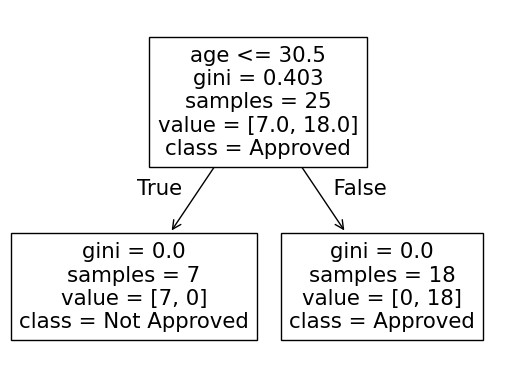

In [38]:
from sklearn.tree import plot_tree
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Approved" , "Approved"]
)
plt.show()

In [39]:
print(model.get_depth())

1


In [40]:
print(model.get_n_leaves())

2


# Feature Importance

In [41]:
imp = pd.Series(
    model.feature_importances_ , 
    index = X.columns
)
print(imp)

age                 1.0
income              0.0
credit_score        0.0
loan_amount         0.0
employment_years    0.0
existing_loans      0.0
dependents          0.0
loan_term           0.0
dtype: float64


# Control Overfitting

In [44]:
train_score = []
test_score = []
depth = [1,2,3,4,5,6,7,8]
for i in depth:
    model = DecisionTreeClassifier(criterion="gini",random_state=42,max_depth=i)
    model.fit(X_train , Y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_score.append(accuracy_score(Y_train , train_pred))
    test_score.append(accuracy_score(Y_test , test_pred))
print(train_pred)
print(test_pred)

[0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 0 0 1 1 1 1 1 1]
[0 0 1 1 1 1 1]


In [45]:
model = DecisionTreeClassifier(criterion="gini",random_state=42,max_depth=4)
model.fit(X_train , Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Create new data for student

In [47]:
new_customers = pd.DataFrame({
    "age": [29, 37, 45, 52, 33],
    "income": [36000, 58000, 82000, 105000, 45000],
    "credit_score": [615, 695, 755, 790, 650],
    "loan_amount": [200000, 300000, 400000, 500000, 350000],
    "employment_years": [3, 7, 11, 15, 5],
    "existing_loans": [2, 1, 0, 0, 2],
    "dependents": [2, 1, 2, 1, 3],
    "loan_term": [15, 20, 25, 20, 30]
})

prediction = model.predict(new_customers)
print("Predictions:", prediction)

Predictions: [0 1 1 1 1]
